# Euclidean Object Zoo

This notebook visualizes several ready-made geometric objects from the Euclidean zoo.

In [26]:
from pathlib import Path
import sys
import math

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'pyproject.toml').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from geo import Ball, Cube, EllipsoidSurface, FloatPoint, HalfPlane, PlanarAngle

In [27]:
def membership_grid(obj, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), size=220):
    xs = np.linspace(xlim[0], xlim[1], size)
    ys = np.linspace(ylim[0], ylim[1], size)
    grid = np.zeros((size, size), dtype=float)
    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            grid[j, i] = 1.0 if FloatPoint(x, y) in obj else 0.0
    return xs, ys, grid


def ordered_polyline(mesh):
    if not mesh.cells or not all(len(cell) == 2 for cell in mesh.cells):
        return None

    adjacency = {index: set() for index in range(len(mesh.vertices))}
    for start, end in mesh.cells:
        adjacency[start].add(end)
        adjacency[end].add(start)

    degrees = {len(neighbors) for neighbors in adjacency.values()}
    if degrees == {2}:
        start = 0
        order = [start]
        previous = None
        current = start
        while True:
            choices = sorted(adjacency[current] - ({previous} if previous is not None else set()))
            if not choices:
                break
            nxt = choices[0]
            if nxt == start:
                break
            order.append(nxt)
            previous, current = current, nxt
            if len(order) > len(mesh.vertices):
                return None
        return order

    endpoints = [index for index, neighbors in adjacency.items() if len(neighbors) == 1]
    if len(endpoints) != 2:
        return None

    start = min(endpoints)
    order = [start]
    previous = None
    current = start
    while True:
        choices = sorted(adjacency[current] - ({previous} if previous is not None else set()))
        if not choices:
            break
        nxt = choices[0]
        order.append(nxt)
        previous, current = current, nxt
        if len(order) > len(mesh.vertices):
            return None
    return order


def draw_mesh(
    ax,
    obj,
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
    color='black',
    linewidth=2.0,
    resolution=192,
    projection_axes=(0, 1),
    fill_color=None,
):
    try:
        mesh = obj.mesh(resolution=resolution, bounds=(xlim, ylim))
    except (AttributeError, NotImplementedError, ValueError):
        return False

    if mesh.dim > 2:
        mesh = mesh.projected(projection_axes)
    if mesh.dim != 2 or not mesh.vertices:
        return False

    vertices = np.asarray([tuple(vertex) for vertex in mesh.vertices], dtype=float)
    polyline = ordered_polyline(mesh)
    if fill_color is not None and polyline is not None and len(polyline) >= 3:
        polygon = vertices[polyline]
        ax.fill(
            polygon[:, 0],
            polygon[:, 1],
            color=fill_color,
            alpha=0.18,
            zorder=1,
        )

    edge_cells = mesh.edge_indices()
    if not edge_cells:
        ax.scatter(vertices[:, 0], vertices[:, 1], s=20.0, c=color)
        return True

    for start, end in edge_cells:
        if color != 'black':
            ax.plot(
                vertices[[start, end], 0],
                vertices[[start, end], 1],
                color='white',
                linewidth=linewidth + 3.0,
                alpha=0.95,
                zorder=2,
            )
        ax.plot(
            vertices[[start, end], 0],
            vertices[[start, end], 1],
            color=color,
            linewidth=linewidth,
            zorder=3,
        )
    if color != 'black':
        sample = vertices[::max(1, len(vertices) // 32)]
        ax.scatter(
            sample[:, 0],
            sample[:, 1],
            s=42.0,
            c=color,
            edgecolors='white',
            linewidths=1.1,
            zorder=4,
        )
    return True


def plot_object(ax, obj, title, xlim=(-2.5, 2.5), ylim=(-2.5, 2.5)):
    xs, ys, grid = membership_grid(obj, xlim=xlim, ylim=ylim)
    has_fill = bool(np.any(grid))
    ax.set_facecolor('#fff7f7' if not has_fill else 'white')
    if np.any(grid):
        ax.imshow(
            grid,
            extent=(xs[0], xs[-1], ys[0], ys[-1]),
            origin='lower',
            cmap='Blues',
            alpha=0.85,
            interpolation='nearest',
        )
    draw_mesh(
        ax,
        obj,
        xlim=xlim,
        ylim=ylim,
        color='black' if has_fill else '#d62728',
        linewidth=2.0 if has_fill else 4.0,
        fill_color=None if has_fill else '#ff9896',
    )
    ax.set_title(title)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)


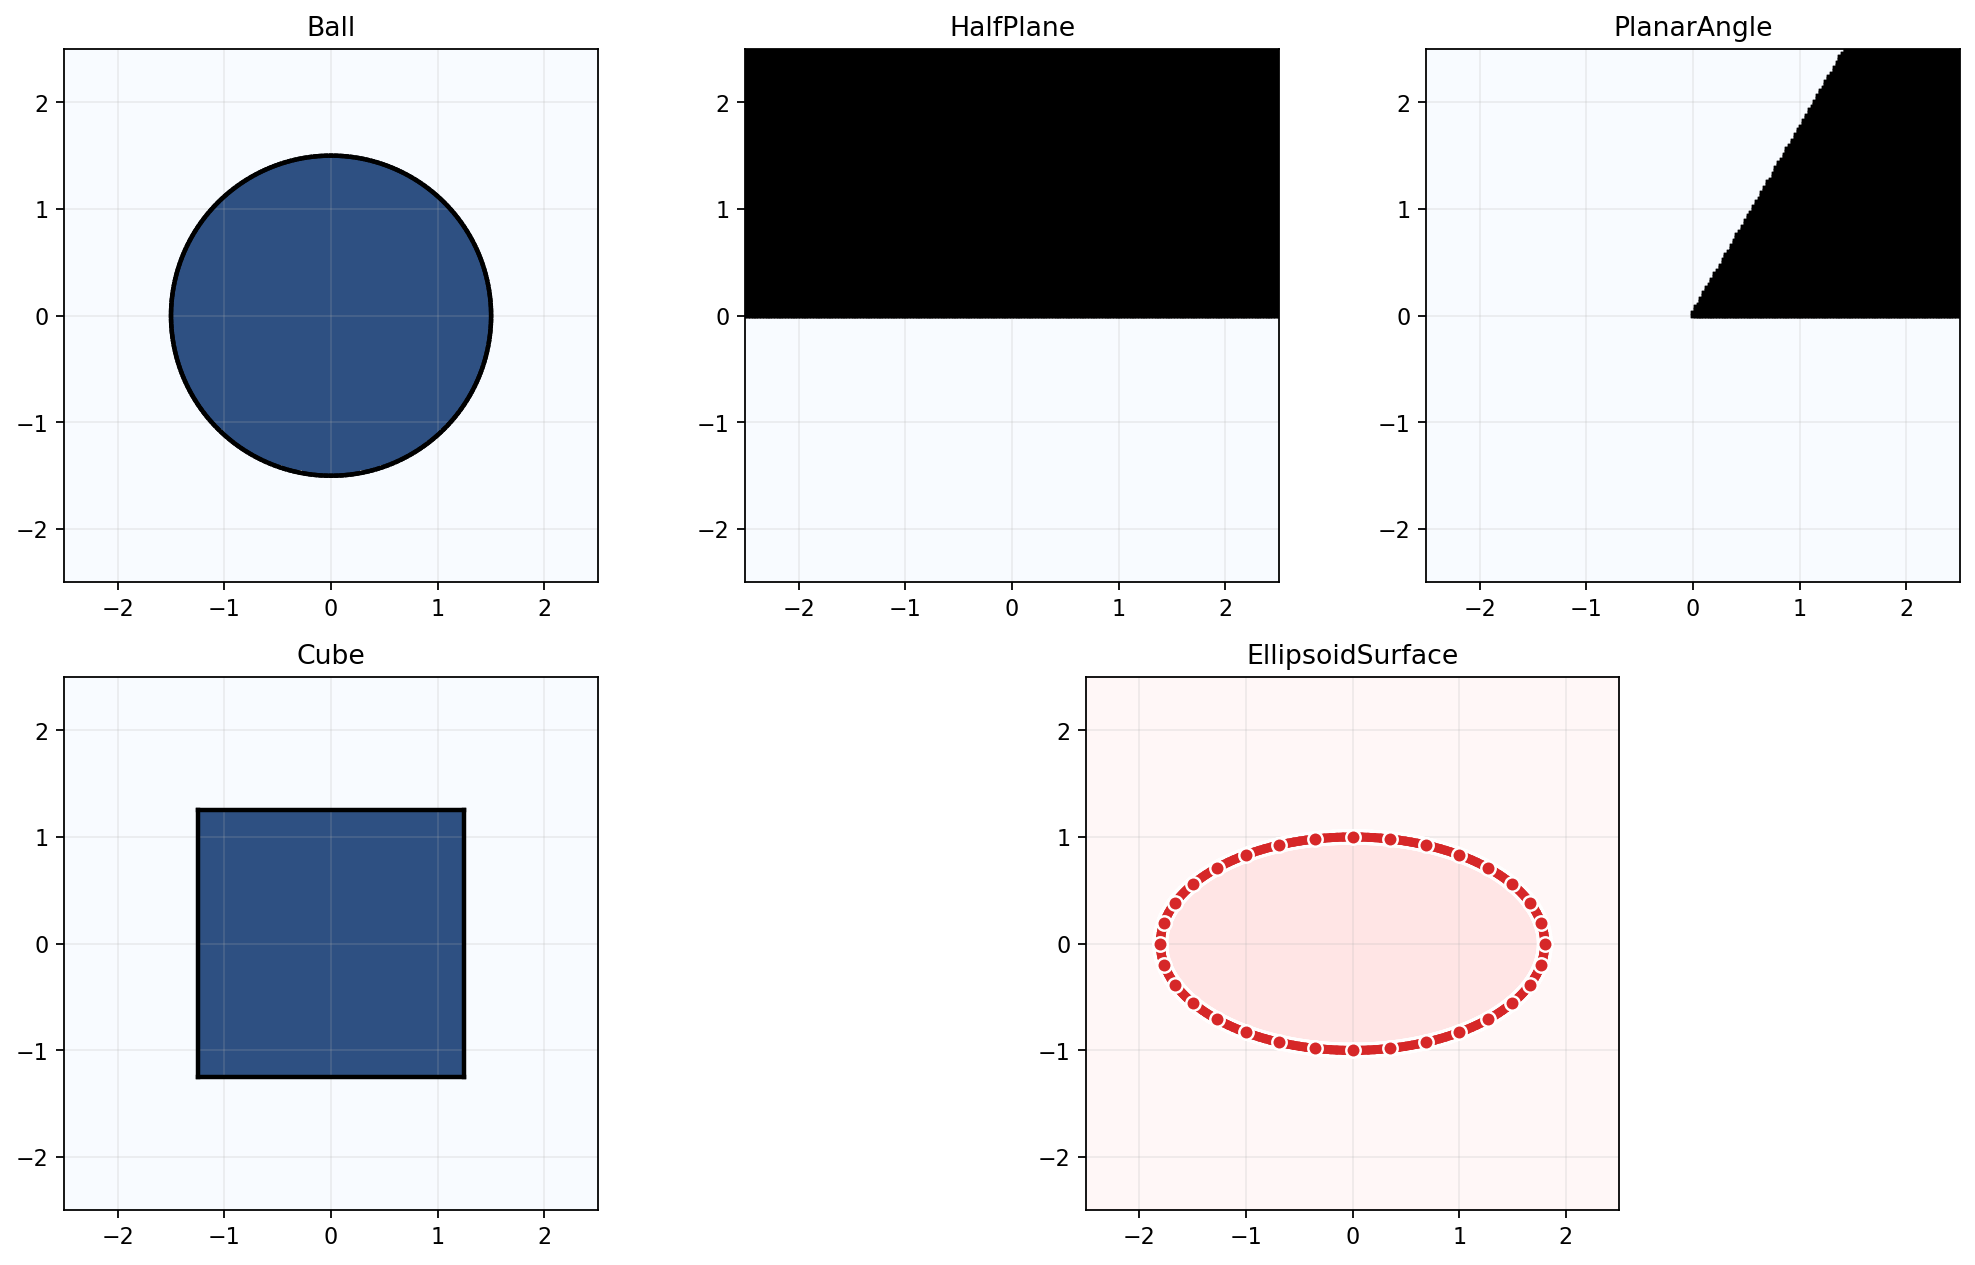

In [1]:
objects = {
    'Ball': Ball(FloatPoint(0.0, 0.0), 1.5),
    'HalfPlane': HalfPlane((0.0, 1.0), offset=0.0),
    'PlanarAngle': PlanarAngle(FloatPoint(0.0, 0.0), 0.0, math.pi / 3.0),
    'Cube': Cube(FloatPoint(0.0, 0.0), 1.25),
    'EllipsoidSurface': EllipsoidSurface(
        FloatPoint(0.0, 0.0),
        ((1.8, 0.0), (0.0, 1.0)),
    ),
}

fig, axes = plt.subplot_mosaic(
    [
        ['Ball', 'HalfPlane', 'PlanarAngle'],
        ['Cube', 'EllipsoidSurface', 'EllipsoidSurface'],
    ],
    figsize=(13, 8),
)
for title, obj in objects.items():
    plot_object(axes[title], obj, title)
fig.tight_layout()
